 # Phần 1: Khảo Sát Dữ Liệu (Exploratory Data Analysis — EDA)
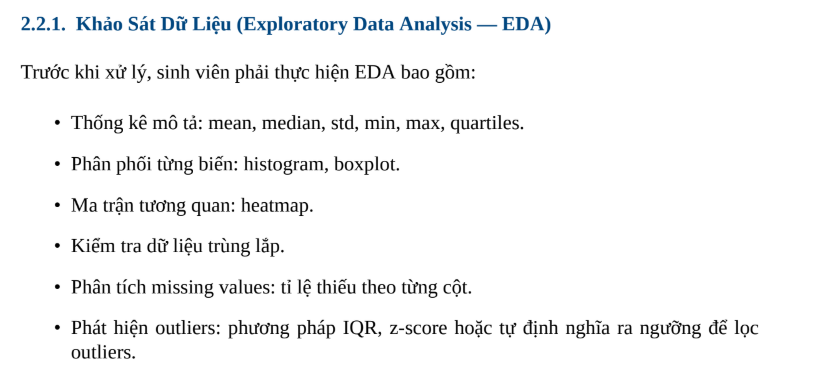

## 1. Kiểm tra chất lượng dữ liệu cơ bản

### 1.1. Thống kê mô tả

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style cho đồ thị
sns.set_theme(style="whitegrid")

# Load dữ liệu
df = pd.read_csv('data/AmesHousing.csv')

# Loại bỏ khoảng trắng thừa trong tên cột
df.columns = df.columns.str.strip()

print(f"Kích thước bộ dữ liệu: {df.shape}")

# Thống kê mô tả (mean, median, std, min, max, quartiles)
display(df.describe())

# Xem qua các biến phân loại
display(df.describe(exclude='number'))

Kích thước bộ dữ liệu: (2930, 82)


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
count,2930,2930,198,2930,2930,2930,2930,2930,2930,2930,...,2773,2771,2771,2771,2930,13,572,106,2930,2930
unique,7,2,2,4,4,3,5,3,28,9,...,6,3,5,5,3,4,4,5,10,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,2273,2918,120,1859,2633,2927,2140,2789,443,2522,...,1731,1231,2615,2665,2652,4,330,95,2536,2413


### 1.2. Kiểm tra dữ liệu trùng lắp

In [2]:
num_duplicates = df.duplicated().sum()
print(f"Số lượng dòng dữ liệu bị trùng lắp (Duplicates): {num_duplicates}")

Số lượng dòng dữ liệu bị trùng lắp (Duplicates): 0


#### Nhận xét: Kiểm tra dữ liệu trùng lắp
Qua hàm `duplicated()`, ta thấy bộ dữ liệu Ames Housing không có dòng dữ liệu nào bị trùng lắp hoàn toàn (0 duplicates). Điều này chứng tỏ khâu thu thập dữ liệu gốc đã được quản lý định danh (thông qua mã PID của từng căn nhà) rất tốt. Do đó, nhóm không cần thực hiện bước xóa dòng trùng (drop duplicates) trong quá trình tiền xử lý.

## 2. Trực quan hóa dữ liệu (Histogram & Boxplot)

### 2.1. Khảo sát Biến mục tiêu (SalePrice)

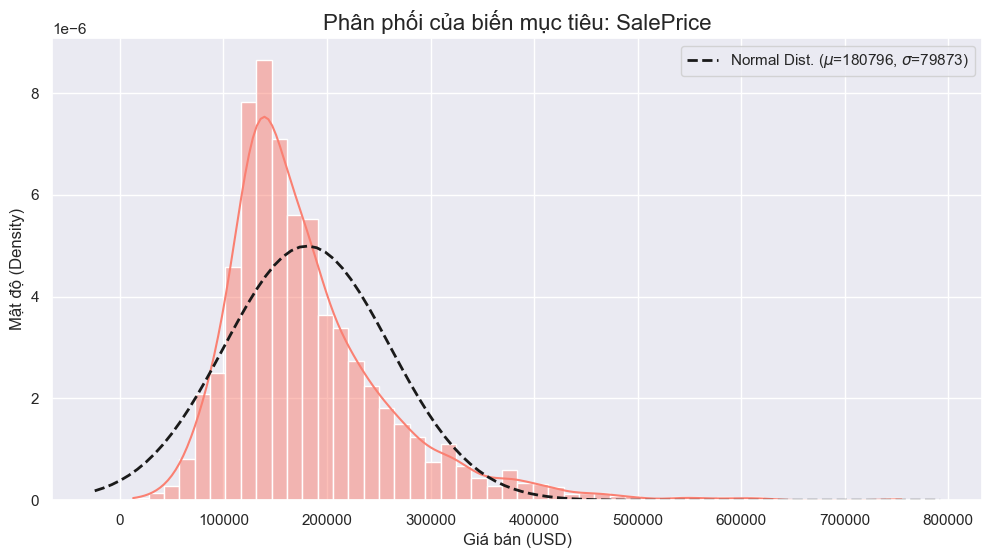

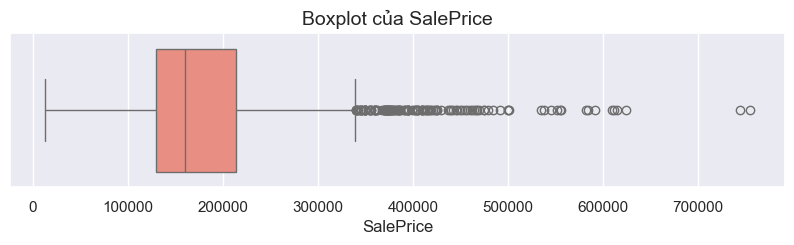

In [3]:
from scipy.stats import norm

# Thiết kế biểu đồ phân tích cho biến mục tiêu
plt.figure(figsize=(12, 6))

# Vẽ Histogram kết hợp đường KDE
sns.histplot(df['SalePrice'], kde=True, stat="density", color="salmon", bins=50)

# Chèn thêm đường cong phân phối chuẩn (Normal Distribution) để so sánh độ lệch
mu, std = norm.fit(df['SalePrice'].dropna())
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, linestyle='--', label=rf'Normal Dist. ($\mu$={mu:.0f}, $\sigma$={std:.0f})')

plt.title('Phân phối của biến mục tiêu: SalePrice', fontsize=16)
plt.xlabel('Giá bán (USD)', fontsize=12)
plt.ylabel('Mật độ (Density)', fontsize=12)
plt.legend()
plt.show()

# Vẽ Boxplot cho SalePrice để soi outliers của y
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['SalePrice'], color='salmon')
plt.title('Boxplot của SalePrice', fontsize=14)
plt.show()

#### Nhận xét về Biến mục tiêu (Target Variable Analysis)
* **Phân phối:** Biểu đồ Histogram cho thấy `SalePrice` bị lệch phải (Right-skewed) rõ rệt. Đỉnh của phân phối tập trung ở khoảng 130,000 - 160,000 USD, nhưng có một dải đuôi dài kéo về phía các mức giá cao (trên 500,000 USD).
* **So sánh với Phân phối chuẩn:** Đường cong thực tế (Salmon) lệch đáng kể so với đường lý thuyết (Black dashed), cho thấy dữ liệu không tuân theo phân phối chuẩn.
* **Outliers:** Boxplot xác nhận sự tồn tại của nhiều giá trị ngoại lệ ở phía cận trên (giá cao).
* **Kết luận cho OLS:** Để thỏa mãn giả định về phân phối chuẩn của phần dư trong mô hình OLS, việc áp dụng phép biến đổi **Log-transformation** cho `SalePrice` là bắt buộc trước khi đưa vào huấn luyện.

### 2.2. Khảo sát Biến dự báo (Predictors)

12 biến được chọn để vẽ phân phối: ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF', 'Full Bath', 'Mas Vnr Area', 'TotRms AbvGrd', 'Fireplaces', 'BsmtFin SF 1', 'Lot Frontage']


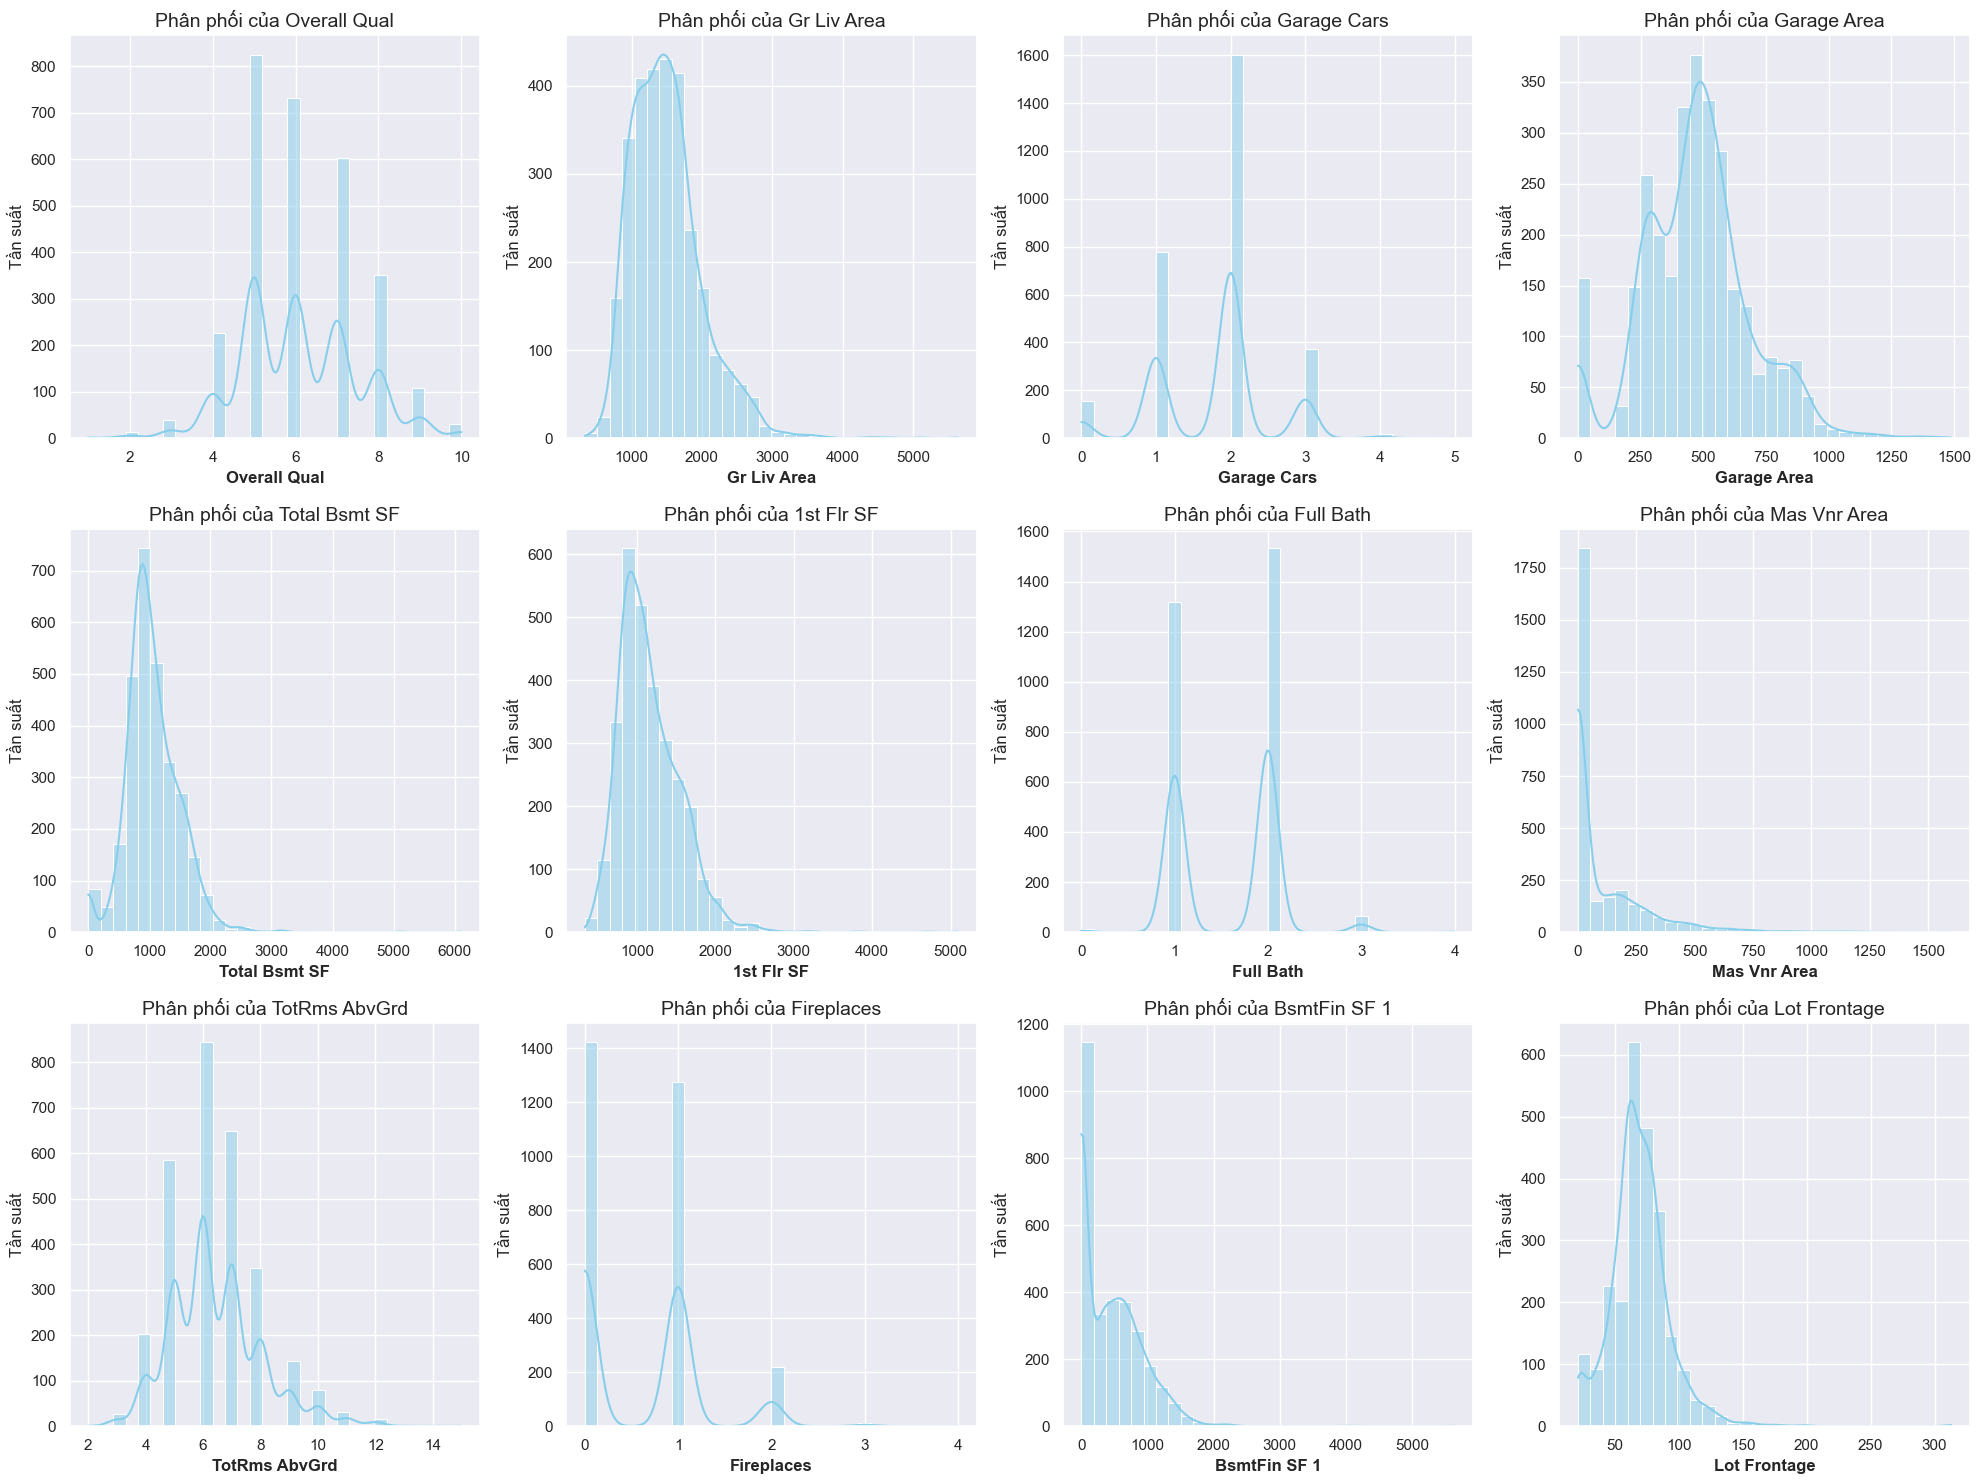

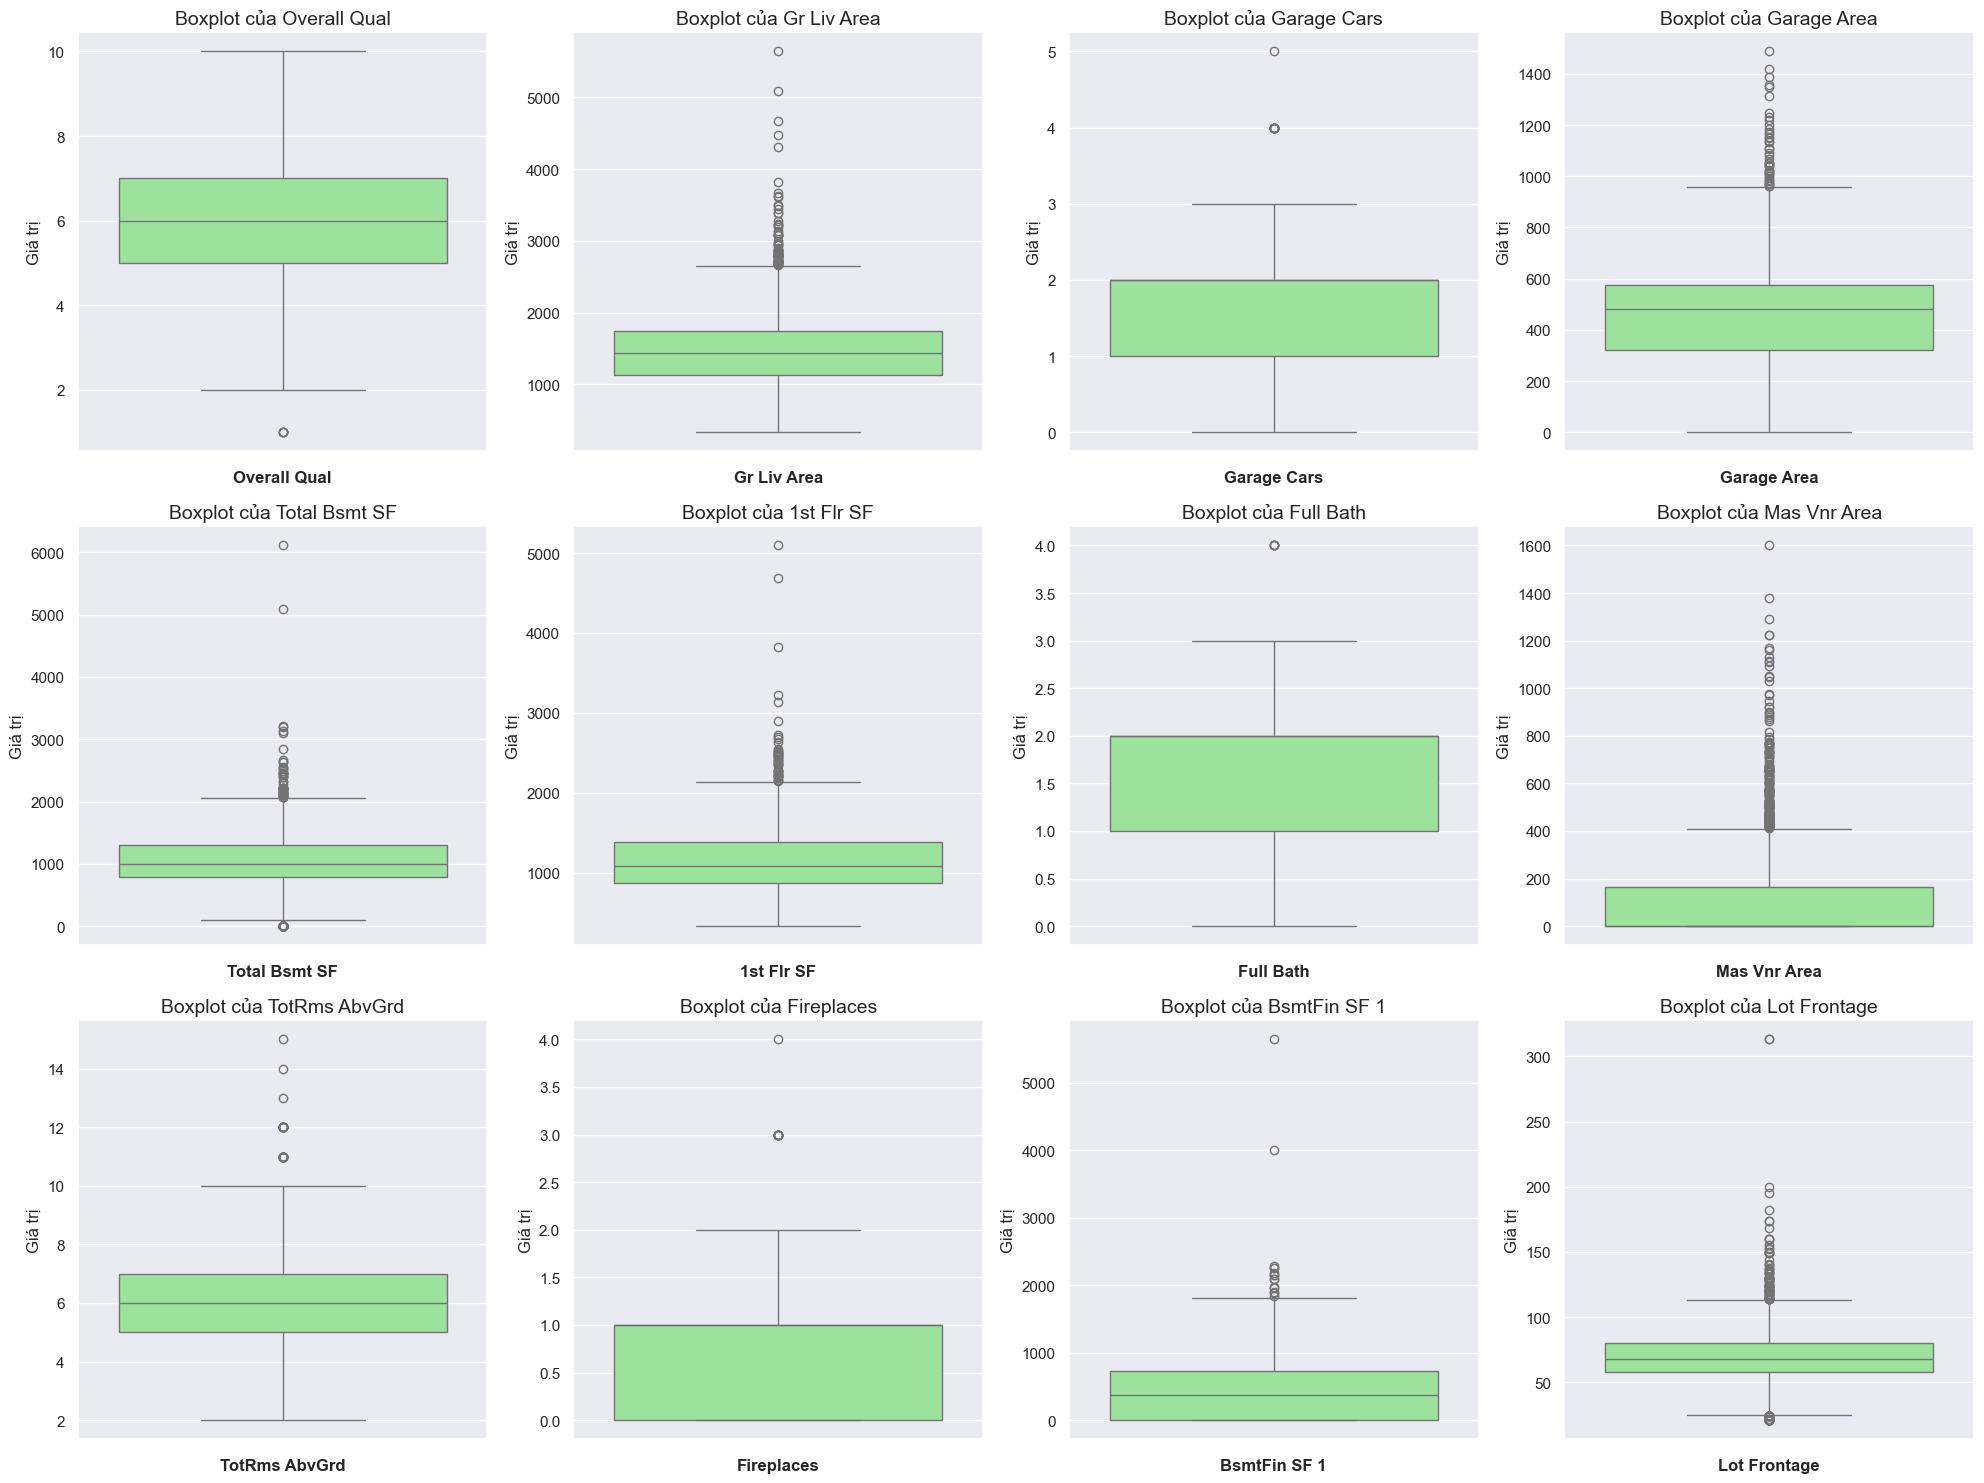

In [4]:
# Tìm các biến có tương quan cao nhất với SalePrice để ưu tiên khảo sát
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Lấy top 30 biến tương quan mạnh nhất với SalePrice
top_30_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(30).index

# Định nghĩa danh sách các biến mang tính chất thời gian (năm/tháng)
temporal_cols = ['Year Built', 'Year Remod/Add', 'Garage Yr Blt', 'Yr Sold', 'Mo Sold']

# Lọc ra top các biến tương quan cao, bỏ qua biến mục tiêu (index 0)
# và bỏ qua các biến nằm trong danh sách temporal_cols
predictors_to_plot = [col for col in top_30_features[1:] if col not in temporal_cols][:12]

print(f"12 biến được chọn để vẽ phân phối: {predictors_to_plot}")

# Vẽ lưới Histogram 3x4
plt.figure(figsize=(20, 15))
for i, col in enumerate(predictors_to_plot, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Phân phối của {col}', fontsize=14)
    plt.xlabel(col, fontsize=12, fontweight='bold')
    plt.ylabel('Tần suất', fontsize=12)
plt.tight_layout()
plt.show()

# Vẽ lưới Boxplot 3x4
plt.figure(figsize=(20, 15))
for i, col in enumerate(predictors_to_plot, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot của {col}', fontsize=14)
    plt.ylabel('Giá trị', fontsize=12)
    plt.xlabel(col, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#### Nhận xét về Phân phối của các Biến dự báo
Qua quan sát biểu đồ Histogram của 12 biến độc lập quan trọng nhất, ta rút ra các đặc điểm sau:

* **Các biến đo lường diện tích (`Gr Liv Area`, `Total Bsmt SF`, `1st Flr SF`):** Hầu hết đều có xu hướng lệch phải (Right-skewed). Điều này phản ánh thực tế cấu trúc nhà ở: đại đa số là nhà có diện tích trung bình, chỉ một thiểu số ít là các dinh thự hoặc nhà có diện tích cực lớn.
* **Các biến đánh giá chất lượng (`Overall Qual`, `Garage Cars`, `Full Bath`):** Có dạng phân phối đa đỉnh (Multimodal) hoặc phân bố theo cụm rời rạc. Đây là đặc trưng hiển nhiên của các biến mang tính chất thứ bậc (Ordinal) hoặc số đếm (Count).
* **Đề xuất xử lý:** Sự lệch phải của các biến diện tích có thể làm tăng phương sai của phần dư trong mô hình OLS. Nhóm sẽ cân nhắc áp dụng phép biến đổi Logarit (Log-transform) cho các biến số học liên tục bị lệch nặng để đưa chúng về dạng chuẩn hơn trong bước Pipeline.

#### Nhận xét về Giá trị ngoại lệ (Visual Outliers) của các Biến dự báo
Qua quan sát hình dáng biểu đồ Boxplot, ta nhận thấy sự xuất hiện của rất nhiều điểm ngoại lệ (các chấm đen nằm ngoài râu của đồ thị):

* **Các điểm đòn bẩy tiềm năng (Potential Leverage Points):** Dễ thấy nhất ở biến `Gr Liv Area` và `Total Bsmt SF`. Có những quan sát nằm tách biệt hoàn toàn ở phía trên đỉnh đồ thị (đại diện cho các căn nhà có diện tích cực lớn). Trong lý thuyết OLS, đây là những điểm có nguy cơ trở thành "đòn bẩy", kéo lệch đường hồi quy của toàn bộ tập dữ liệu.
* **Các biến tiện ích đặc thù:** Những biến như `Mas Vnr Area` (Diện tích ốp gạch/đá) hay `Wood Deck SF` (Diện tích sàn gỗ) có mật độ điểm ngoại lệ rất dày đặc. Lý do trực quan là phần lớn các căn nhà không có tiện ích này (giá trị = 0), khiến phần thân hộp (hộp chứa 50% dữ liệu) bị bóp nghẹt lại, đẩy các giá trị > 0 ra ngoài khoảng râu đồ thị.
* **Định hướng bước tiếp theo:** Từ những quan sát trực quan này, nhóm sẽ tiến hành định lượng cụ thể số lượng ngoại lệ bằng công thức thống kê ở phần "Phân tích chuyên sâu" bên dưới để có cơ sở đưa ra thuật toán xử lý (Winsorization) trong `DataPipeline`.

### 2.3. Đánh giá mức độ tương quan (Heatmap)

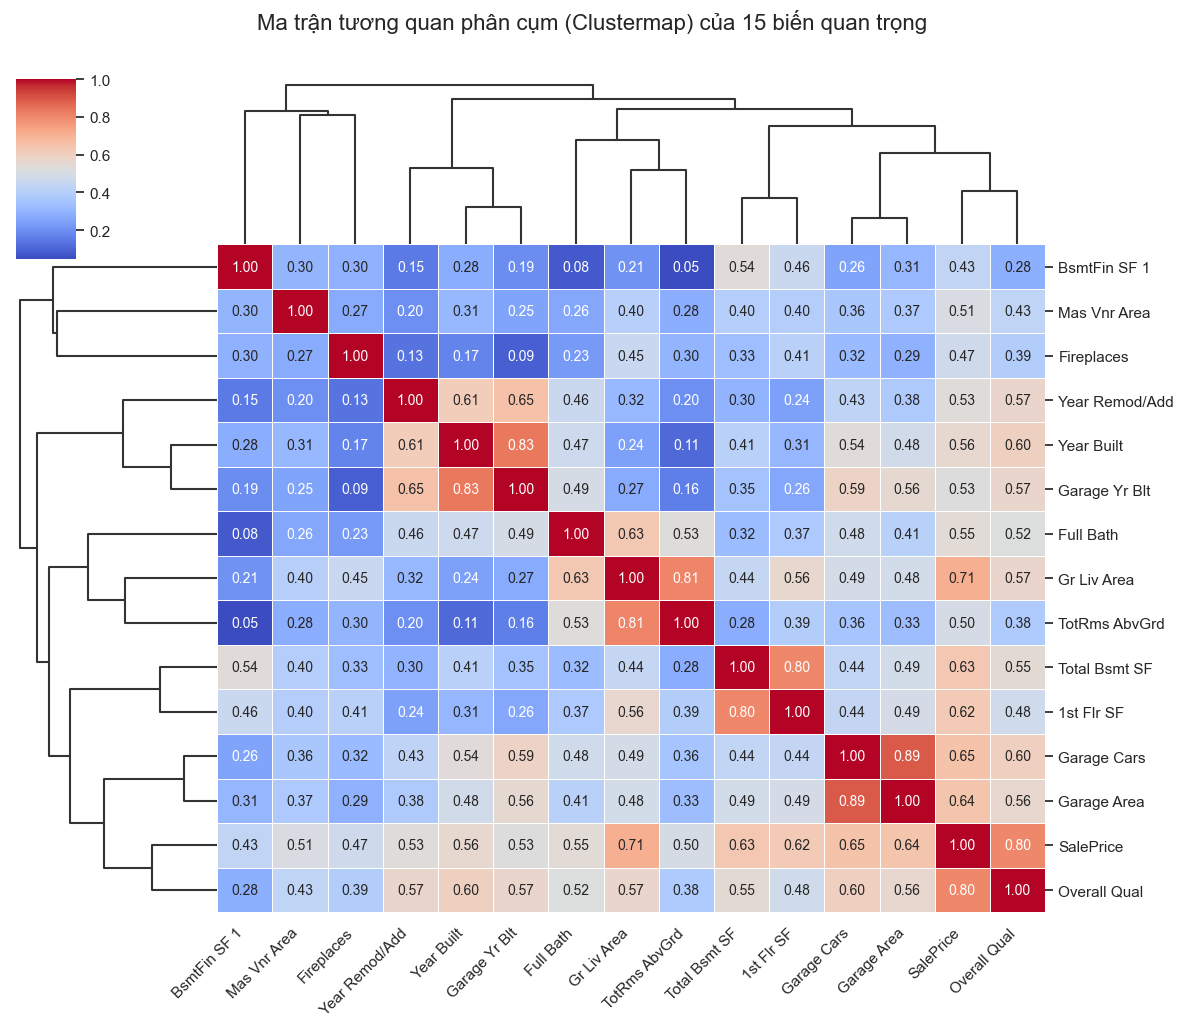

In [5]:
# Lấy top 15 biến có độ tương quan cao nhất với SalePrice
top_15_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(15).index
top_15_corr = df[top_15_features].corr()

# Vẽ Clustermap để thuật toán tự động gom các biến đa cộng tuyến lại gần nhau
cluster = sns.clustermap(top_15_corr,
                         annot=True,
                         fmt=".2f",
                         cmap='coolwarm',
                         linewidths=0.5,
                         figsize=(12, 10), # Clustermap dùng figsize bên trong hàm
                         annot_kws={"size": 10},
                         tree_kws={"linewidths": 1.5}) # Làm nét đường cây phân cụm

cluster.fig.suptitle('Ma trận tương quan phân cụm (Clustermap) của 15 biến quan trọng', fontsize=16, y=1.05)

plt.setp(cluster.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.setp(cluster.ax_heatmap.get_yticklabels(), rotation=0)

plt.show()

#### Nhận xét về Ma trận tương quan phân cụm (Clustermap)
Thay vì sắp xếp thủ công, nhóm sử dụng thuật toán Phân cụm phân cấp (Hierarchical Clustering) thông qua biểu đồ Clustermap để máy tính **tự động** tính toán khoảng cách và gom nhóm các biến có độ tương quan cao lại với nhau. Qua quan sát, ta rút ra các kết luận quan trọng:

* **Các biến dự báo "át chủ bài":** `Overall Qual` (Chất lượng tổng thể) và `Gr Liv Area` (Diện tích sinh hoạt) đã khẳng định vị thế là 2 biến độc lập có tác động mạnh mẽ nhất đến `SalePrice`. Đây sẽ là các biến mang trọng số cao trong phương trình hồi quy.
* **Phát hiện Đa cộng tuyến (Multicollinearity) tự động:** Nhờ cây phân cụm (dendrogram), thuật toán đã nhóm thành công 4 cụm biến (các ô màu đỏ sẫm tạo thành khối vuông) có hiện tượng đa cộng tuyến rất cao:
  1. **`Garage Cars` & `Garage Area`:** Sức chứa (số xe) và diện tích vật lý của gara tỉ lệ thuận trực tiếp với nhau.
  2. **`TotRms AbvGrd` & `Gr Liv Area`:** Tổng số phòng và tổng diện tích sinh hoạt trên mặt đất về cơ bản đang đo lường cùng một quy mô không gian.
  3. **`1st Flr SF` & `Total Bsmt SF`:** Khuôn viên diện tích mặt bằng tầng 1 thường được xây dựng khớp với diện tích tầng hầm bên dưới nó.
  4. **`Year Built` & `Garage Yr Blt`:** Đại đa số gara đều được xây dựng cùng năm với thời điểm cất nhà chính.
* **Đề xuất xử lý cho mô hình OLS:** Hiện tượng đa cộng tuyến sẽ làm ma trận thiết kế bị suy biến và gây nhiễu các hệ số $\beta$. Ở bước `DataPipeline`, nhóm đề xuất sẽ **chỉ giữ lại một biến** trong mỗi cặp để đưa vào huấn luyện. Điển hình như cặp số 4, nhóm sẽ loại bỏ `Garage Yr Blt` (vì cột này chứa 159 giá trị khuyết) và giữ lại `Year Built` nhằm tối ưu hóa bộ dữ liệu.

#### 2.4. Khảo sát tính tuyến tính giữa các Biến độc lập và Biến mục tiêu (SalePrice)

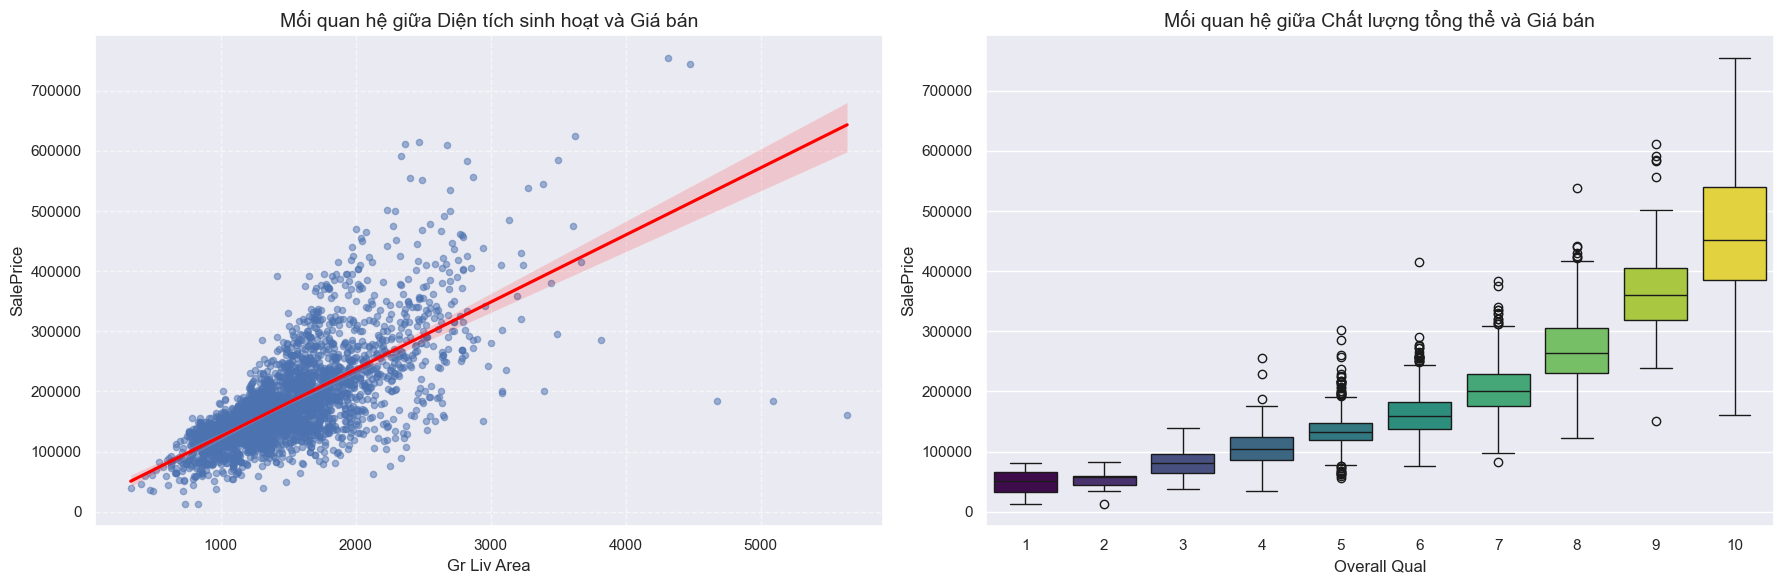

In [6]:
plt.figure(figsize=(18, 6))

# 1. Gr Liv Area vs SalePrice (Biến diện tích liên tục)
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='Gr Liv Area', y='SalePrice',
            scatter_kws={'alpha':0.5, 's':20},
            line_kws={'color':'red'})
plt.title('Mối quan hệ giữa Diện tích sinh hoạt và Giá bán', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Overall Qual vs SalePrice (Biến chất lượng rời rạc)
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Overall Qual', y='SalePrice', hue='Overall Qual', palette='viridis', legend=False)
plt.title('Mối quan hệ giữa Chất lượng tổng thể và Giá bán', fontsize=14)

plt.tight_layout()
plt.show()

#### Nhận xét về tính tuyến tính và tương quan
Biểu đồ Scatter Plot và Boxplot kết hợp với đường hồi quy (Red line) cho thấy:

* **Tính tuyến tính:** Biến `Gr Liv Area` thể hiện một mối quan hệ tuyến tính thuận rất rõ rệt với `SalePrice`. Khi diện tích tăng, giá nhà có xu hướng tăng theo một tỉ lệ ổn định. Điều này cho thấy mô hình hồi quy tuyến tính là một lựa chọn hợp lý để thử nghiệm ở bước tiếp theo.
* **Hiện tượng "loe phễu":** Ở biểu đồ bên trái, ta thấy khi diện tích càng lớn, các điểm dữ liệu càng phân tán rộng hơn (hình cái loa). Đây là dấu hiệu của phương sai thay đổi (Heteroscedasticity), củng cố thêm lý do tại sao nhóm cần áp dụng Log-transform ở bước sau để "nén" phương sai này lại.
* **Biến chất lượng:** Với `Overall Qual`, giá nhà tăng theo bậc thang khi chất lượng tăng. Tuy nhiên, ở các mức chất lượng cao nhất (9 và 10), sự biến động về giá là cực lớn, cho thấy chất lượng chỉ là điều kiện cần, còn giá cuối cùng phụ thuộc thêm nhiều yếu tố khác.

## 3. Phân tích chuyên sâu

### 3.1. Phân tích Missing Values

Có 27 biến bị missing:



,Số lượng,Tỷ lệ %
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
Fireplace Qu,1422,48.532423
Lot Frontage,490,16.723549
Garage Qual,159,5.426621
Garage Cond,159,5.426621
Garage Yr Blt,159,5.426621


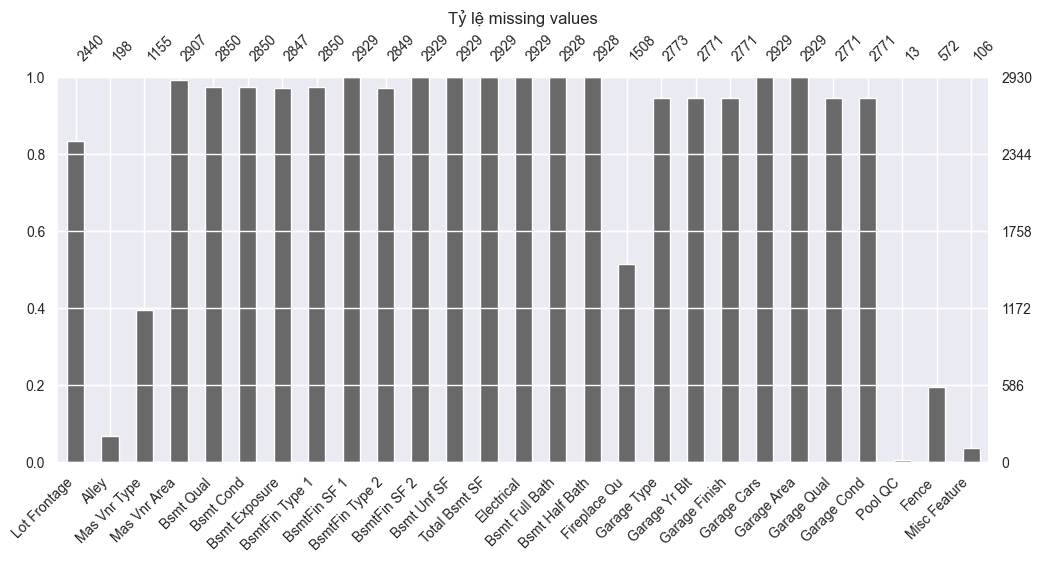

In [7]:
import missingno as msno
import matplotlib.pyplot as plt

# Thống kê số lượng và tỷ lệ missing
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Số lượng': missing, 'Tỷ lệ %': missing_pct})
missing_report = missing_report[missing_report['Số lượng'] > 0].sort_values('Tỷ lệ %', ascending=False)
print(f"Có {len(missing_report)} biến bị missing:\n")
display(missing_report)

# Chỉ vẽ các cột có missing
missing_cols = df.columns[df.isnull().any()].tolist()
if missing_cols:
    msno.bar(df[missing_cols], figsize=(12, 5), fontsize=10)
    plt.title("Tỷ lệ missing values")
    plt.show()
else:
    print("Không có cột nào bị missing.")

### Phân tích tổng quan dữ liệu khuyết (Missing Values)

Thay vì liệt kê đơn lẻ, việc phân tích dữ liệu khuyết được nhóm chia thành các cụm đặc trưng có cùng bản chất nghiệp vụ để dễ dàng nhận diện pattern (quy luật bị khuyết). Trực quan hóa dữ liệu cho thấy các giá trị `NaN` không phân bố ngẫu nhiên mà tập trung vào 3 nhóm chính:

1. **Nhóm khuyết diện rộng (> 80%):** Bao gồm `Pool QC` (99.5%), `Misc Feature` (96.3%), `Alley` (93.2%), `Fence` (80.4%). Đây là các tiện ích "xa xỉ" hoặc không phổ biến. Tỉ lệ khuyết cao phản ánh thực tế phần lớn các ngôi nhà không sở hữu các tiện ích này.
2. **Nhóm khuyết theo cụm cấu trúc (Structural Clusters - ~2.5% đến 5%):**
   - **Cụm Garage:** Các biến `Garage Type`, `Garage Finish`, `Garage Qual`, `Garage Cond`, `Garage Yr Blt` luôn bị khuyết cùng lúc trên cùng các dòng dữ liệu.
   - **Cụm Basement (Tầng hầm):** Tương tự, `Bsmt Qual`, `Bsmt Cond`, `Bsmt Exposure`, `BsmtFin Type 1/2` có pattern khuyết đồng thời.
   $\rightarrow$ Trạng thái khuyết này có tính hệ thống cao, đại diện cho việc ngôi nhà hoàn toàn không có Gara hoặc Tầng hầm.
3. **Nhóm khuyết rời rạc (MAR / Lỗi nhập liệu):** - `Lot Frontage` (~16.7%): Mọi lô đất đều phải có mặt tiền tiếp giáp, việc khuyết dữ liệu có thể do khó khăn trong việc đo đạc ở một số khu vực nhất định.
   - `Mas Vnr Type / Area` và `Electrical`: Tỉ lệ khuyết rất nhỏ, mang dấu vết của sự bỏ sót ngẫu nhiên trong quá trình số hóa dữ liệu.

*Nhận định:* Phần lớn dữ liệu khuyết trong tập Ames Housing chứa đựng **thông tin nghiệp vụ quan trọng** (nhà không có tiện ích) thay vì lỗi thu thập. Do đó, tuyệt đối không được dùng phương pháp xóa dòng (Listwise Deletion) để tránh mất mát thông tin nghiêm trọng.

### 3.2. Phát hiện Outliers bằng phương pháp IQR

In [8]:
# 1. ĐỊNH LƯỢNG OUTLIERS BẰNG PHƯƠNG PHÁP IQR
outlier_counts = {}
iqr_zero_cols = []

def count_outliers_iqr_advanced(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    # Bắt lỗi: Nếu IQR = 0, phương pháp này trở nên vô nghĩa
    if IQR == 0:
        return -1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    return len(outliers)

# Quét qua toàn bộ các cột numeric
for col in numeric_cols:
    count = count_outliers_iqr_advanced(df, col)
    if count == -1:
        iqr_zero_cols.append(col)
    else:
        outlier_counts[col] = count

# Hiển thị bảng Outliers hợp lệ
outliers_df = pd.DataFrame(list(outlier_counts.items()), columns=['Biến (Feature)', 'Số lượng Outliers'])
outliers_df['Tỉ lệ (%)'] = (outliers_df['Số lượng Outliers'] / len(df)) * 100
outliers_df = outliers_df[outliers_df['Số lượng Outliers'] > 0].sort_values(by='Số lượng Outliers', ascending=False)

print("BẢNG THỐNG KÊ OUTLIERS HỢP LỆ (IQR > 0)")
display(outliers_df.head(10))

print("\nDANH SÁCH CÁC BIẾN KHÔNG THỂ ÁP DỤNG IQR (IQR = 0)")
print(f"Tổng cộng có {len(iqr_zero_cols)} biến. Danh sách chi tiết:")
print(iqr_zero_cols)

# 2. XÁC ĐỊNH ĐIỂM ĐÒN BẨY CỰC ĐOAN
leverage_candidates = df[(df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 300000)]
print(f"\nĐIỂM ĐÒN BẨY TIỀM NĂNG (Gr Liv Area > 4000 & SalePrice < 300k): {len(leverage_candidates)} quan sát")

BẢNG THỐNG KÊ OUTLIERS HỢP LỆ (IQR > 0)


,Biến (Feature),Số lượng Outliers,Tỉ lệ (%)
6,Overall Cond,252,8.600683
2,MS SubClass,208,7.098976
9,Mas Vnr Area,200,6.825939
3,Lot Frontage,187,6.382253
26,Open Porch SF,159,5.426621
29,SalePrice,137,4.675768
4,Lot Area,127,4.334471
12,Total Bsmt SF,123,4.197952
19,Bedroom AbvGr,78,2.662116
15,Gr Liv Area,75,2.559727



DANH SÁCH CÁC BIẾN KHÔNG THỂ ÁP DỤNG IQR (IQR = 0)
Tổng cộng có 9 biến. Danh sách chi tiết:
['BsmtFin SF 2', 'Low Qual Fin SF', 'Bsmt Half Bath', 'Kitchen AbvGr', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val']

ĐIỂM ĐÒN BẨY TIỀM NĂNG (Gr Liv Area > 4000 & SalePrice < 300k): 3 quan sát


#### Nhận xét về Giá trị ngoại lệ & Giới hạn của phương pháp IQR
Trong quá trình định lượng Outliers, nhóm phát hiện một vấn đề mang tính nền tảng của thuật toán IQR: Có nhiều biến sở hữu khoảng tứ phân vị bằng 0 ($IQR = 0$). Nhóm đã tiến hành lọc riêng các biến này ra khỏi bảng thống kê và phân loại thành 2 nhóm bản chất:

1. **Nhóm dữ liệu thưa thớt (Zero-inflated):** Tiêu biểu là `BsmtFin SF 2`, `Enclosed Porch`, `Screen Porch`. Hơn 80% giá trị của các biến này là 0 (nhà không có tiện ích này). Khi $Q1 = 0$ và $Q3 = 0$, mọi giá trị $> 0$ đều bị IQR kết luận là ngoại lệ. Điều này là **vô lý về mặt nghiệp vụ**, vì việc có một cái hiên nhà không thể bị coi là điểm dị thường.
2. **Nhóm dữ liệu thiếu phương sai (Near-constant):** Tiêu biểu là `Kitchen AbvGr`. 99% các căn nhà có đúng 1 nhà bếp ($Q1 = 1, Q3 = 1$). Những căn có 2 bếp sẽ bị IQR bắt lỗi. Thực chất đây là những căn hộ thiết kế đặc biệt (nhà ghép/duplex), việc áp dụng công thức khoảng cách cho biến gần như hằng số này là **không phù hợp**.

**Định hướng xử lý trong Pipeline:**
* **Đối với các biến có IQR bình thường (như `SalePrice`, `Gr Liv Area`):** Nhóm sẽ áp dụng kỹ thuật **Winsorization** (chặn phân vị 1% - 99%) để giảm sát thương của các điểm đòn bẩy.
* **Đối với nhóm $IQR = 0$:** Nhóm hoàn toàn **không áp dụng kỹ thuật gọt Outliers**. Thay vào đó, nếu cần thiết, nhóm sẽ xem xét chuyển đổi chúng thành biến phân loại nhị phân (ví dụ: `Has_Enclosed_Porch`: 1/0) để đưa vào mô hình hiệu quả hơn.

#### Nhận xét về Điểm đòn bẩy
Các điểm có Gr Liv Area > 4000 nhưng SalePrice < 300k là bất thường so với xu hướng chung — diện tích lớn nhưng giá lại thấp. Trong OLS, những điểm này có thể trở thành leverage points làm lệch đường hồi quy. Sẽ được loại khỏi tập train trong DataPipeline.

# Phần 2: Tiền xử lý missing values + Feature Engineering

## 2.1. Phân tích cơ chế Missing Values và Kỹ thuật Xử lý

Không phải mọi giá trị thiếu đều có cùng bản chất. Trước khi chọn kỹ thuật xử lý, cần xác định **cơ chế khuyết** (missing mechanism) của từng nhóm biến, vì chọn sai kỹ thuật sẽ tạo ra dữ liệu mâu thuẫn logic và làm sai lệch mô hình.

---

#### Nhóm 1 — Biến định danh và near-zero variance (DROP)

`Order` và `PID` là số thứ tự và mã định danh, unique mỗi hàng — không mang thông tin dự báo, cần drop trước mọi bước xử lý.

`Utilities` (99.9% = `AllPub`) và `Street` (99.6% = `Pave`) gần như hằng số — không phân biệt được các ngôi nhà với nhau, đưa vào mô hình chỉ tạo nhiễu.

**Kỹ thuật: Drop hoàn toàn.**

---

#### Nhóm 2 — Biến >80% missing: MNAR có cấu trúc (DROP + tạo cờ)

`Pool QC` (99.6%), `Misc Feature` (96.4%), `Alley` (93.2%), `Fence` (80.5%) — tỷ lệ missing quá cao không phải do lỗi ghi chép mà vì đại đa số nhà thực sự **không có** những tiện ích này. Đây là **MNAR (Missing Not At Random)** có cấu trúc.

Tuy nhiên thông tin "có hay không" vẫn có giá trị dự báo, nên trước khi drop cần tạo biến cờ: `Has_Pool`, `Has_Alley`, `Has_Fence`, `Has_Misc_Feature`.

**Kỹ thuật: Tạo cờ binary → Drop cột gốc.**

---

#### Nhóm 3 — Garage: MNAR có cấu trúc + 2 hàng MAR

Khi xác định nhà có garage hay không, **không thể chỉ dựa vào một cột**. Đối chiếu chéo 3 cột cho thấy 157 nhà không có garage, và tất cả biến garage của nhóm này đều null đồng bộ — đây là **MNAR**: nhà không có garage thì không có năm xây, diện tích, chất lượng garage.

Vấn đề điển hình: nếu áp dụng khuôn mẫu "biến số → điền median", `Garage Yr Blt` của 157 nhà không có garage sẽ được điền ~1979 — mâu thuẫn hoàn toàn với `Garage Type = 'None'`. Mô hình OLS sẽ nhận tín hiệu nhiễu: nhà không có garage nhưng lại có năm xây garage.

Ngoài 157 hàng MNAR, còn 2 hàng nhà **có** garage nhưng bị bỏ sót năm xây — đây là **MAR** (lỗi ghi chép), xử lý riêng bằng median theo nhóm thập niên × loại garage.

Đặc biệt, 5 hàng `Garage Type = 'Attchd'` có `Garage Yr Blt < Year Built` — garage đính kèm không thể xây trước nhà, đây là lỗi nhập liệu cần sửa trước khi imputation.

**Kỹ thuật:**
- MNAR (157 hàng): điền `'None'` / `0` — phản ánh "không tồn tại"
- `Garage Finish`, `Qual`, `Cond`: mode theo nhóm `(Garage Type × Overall Qual)` — chất lượng hoàn thiện phụ thuộc kiểu garage và chất lượng tổng thể ngôi nhà

**Kỹ thuật xử lý `Garage Yr Blt`:**
- Không gán giá trị cho nhà không có garage (giữ `NaN`).
- Với 2 hàng MAR (có garage nhưng thiếu năm xây): điền bằng median theo nhóm `(thập niên Year Built × Garage Type)`.
- Sau xử lý, `Garage Yr Blt` chỉ còn `NaN` ở nhóm không có garage — đây là **MNAR có chủ đích**, sẽ được xử lý tiếp trong bước Feature Engineering.

---

#### Nhóm 4 — Basement: MNAR + một số hàng MAR

80 nhà không có tầng hầm (anchor: `Total Bsmt SF = 0` hoặc tổng diện tích các phần = 0). Toàn bộ biến basement của nhóm này đều là **MNAR**.

Tuy nhiên có 3 hàng `Bsmt Exposure` và 1 hàng `BsmtFin Type 2` null trong khi nhà **có** tầng hầm — đây là **MAR** (lỗi bỏ sót khi ghi chép), cần xử lý riêng.

Lưu ý: `Bsmt Unf SF` (diện tích chưa hoàn thiện) không cần imputation — có thể tính trực tiếp từ `Total Bsmt SF - BsmtFin SF 1 - BsmtFin SF 2`, đây là quan hệ kế toán chính xác.

**Kỹ thuật:**
- MNAR: điền `'None'` / `0`
- `Bsmt Exposure` MAR (3 hàng): mode của nhà có tầng hầm = `'No'` (65% giá trị)
- `Bsmt Unf SF`: tính từ phần dư — không dùng imputation
- `Bsmt Qual`: mode theo nhóm quantile `Total Bsmt SF` (tương quan r=0.46 với Bsmt Qual)
- `Bsmt Cond`: điền thẳng `'TA'` — chiếm 89% ở mọi nhóm năm xây, phân nhóm thêm không thay đổi kết quả

---

#### Nhóm 5 — Fireplace Qu: MNAR thuần túy

1,422 hàng `Fireplace Qu = NaN` khi `Fireplaces = 0` — 100% khớp, không có ngoại lệ. Không có lò sưởi thì không có chất lượng lò sưởi. Đây là **MNAR** rõ ràng nhất trong dataset.

**Kỹ thuật: `Fireplaces = 0` → điền `'None'`. Không cần xử lý gì thêm** (trong dataset này không có hàng nào `Fireplaces > 0` mà `Fireplace Qu` null).

---

#### Nhóm 6 — Mas Vnr (Lớp ốp đá/gạch): MNAR + MAR nhỏ

60.3% nhà không có lớp ốp đá — **MNAR**. Anchor được xác định bằng đối chiếu chéo: `Mas Vnr Area > 0` HOẶC `Mas Vnr Type ≠ NaN và ≠ 'None'`.

7 hàng có diện tích ốp đá > 0 nhưng thiếu loại (`Mas Vnr Type = NaN`) — **MAR** (lỗi nhập liệu). Không thể điền mode toàn tập vì phân phối loại ốp đá phụ thuộc diện tích: diện tích nhỏ thường là `BrkFace`, lớn thường là `Stone`.

**Kỹ thuật:**
- MNAR: điền `'None'` / `0`
- MAR (7 hàng thiếu Type): mode theo nhóm diện tích (small/medium/large)

---

#### Nhóm 7 — Lot Frontage: MAR

490 hàng (16.7%) missing. Mọi lô đất đều có mặt tiền — việc thiếu là do **bỏ sót khi đo đạc** → **MAR**. Bằng chứng: tỷ lệ missing thay đổi rõ rệt theo khu vực (`GrnHill`: 100%, `Landmrk`: 100%, `ClearCr`: 54.5%, trong khi nhiều khu vực khác <10%).

Quan trọng hơn, median `Lot Frontage` dao động rất lớn theo neighborhood: từ 21 ft (`BrDale`) đến 92 ft (`NridgHt`), trong khi global median chỉ là 68 ft. Dùng global median sẽ sai lệch lớn cho các khu vực đặc thù.

**Kỹ thuật: Grouped median theo `Neighborhood`** (MV2 — phù hợp với MAR phụ thuộc nhóm). Fallback bằng global median cho 2 neighborhood quá ít mẫu (`GrnHill`, `Landmrk`).

---

#### Nhóm 8 — Electrical: MCAR

Chỉ 1 hàng missing (0.03%), không có quy luật kết hợp với bất kỳ biến nào — **MCAR** thuần túy. `SBrkr` chiếm 91.5% giá trị.

**Kỹ thuật: Điền mode = `'SBrkr'`.**

---

#### Tóm tắt cơ chế và kỹ thuật

| Nhóm | Biến | Cơ chế | Kỹ thuật |
|------|------|---------|-----------|
| Định danh / NZV | `Order`, `PID`, `Utilities`, `Street` | — | Drop |
| >80% missing | `Pool QC`, `Misc Feature`, `Alley`, `Fence` | MNAR | Tạo cờ → Drop |
| Garage (MNAR) | 157 hàng không có garage | MNAR | `'None'` / `0` |
| Garage (MAR) | 2 hàng `Garage Yr Blt` | MAR | Median theo thập niên × loại |
| Garage quality | `Finish`, `Qual`, `Cond` | MAR | Mode theo Garage Type × Overall Qual |
| Basement (MNAR) | 80 hàng không có tầng hầm | MNAR | `'None'` / `0` |
| Basement (MAR) | 3 hàng `Bsmt Exposure`, 1 hàng `BsmtFin Type 2` | MAR | Mode / Mode theo nhóm |
| `Bsmt Unf SF` | 1 hàng | Quan hệ kế toán | Tính từ phần dư |
| Fireplace Qu | 1,422 hàng | MNAR | `'None'` |
| Mas Vnr (MNAR) | 1,768 hàng | MNAR | `'None'` / `0` |
| Mas Vnr (MAR) | 7 hàng thiếu Type | MAR | Mode theo nhóm diện tích |
| Lot Frontage | 490 hàng | MAR | Grouped median theo Neighborhood |
| Electrical | 1 hàng | MCAR | Mode (`SBrkr`) |


Dựa trên phân tích cơ chế ở trên, nhóm triển khai xử lý missing values trong module `data_pipeline.py`. Toàn bộ logic được xây dựng theo **quan hệ nhân-quả** giữa các biến.

Quy trình tiền xử lí có 6 bước tuần tự: xóa biến vô dụng → kiểm tra tính nhất quán → xử lý missing theo từng nhóm → imputation Lot Frontage & Electrical → tạo biến mới → kiểm tra lần cuối (raise lỗi nếu còn missing).

## 2.2. Feature Engineering (Kỹ nghệ Đặc trưng)

Dựa trên nguyên tắc tối ưu hóa thông tin và giảm nhiễu cho mô hình Hồi quy tuyến tính, nhóm tiến hành biến đổi, gộp và tạo mới các đặc trưng (Features) mang ý nghĩa nghiệp vụ cao hơn:

* **1. Biến thời gian (Temporal Features):**
  * Thay vì sử dụng các mốc năm tuyệt đối gây khó khăn cho thuật toán, nhóm chuyển hóa thành các khoảng thời gian tương đối: `Age_At_Sale` (Tuổi của nhà khi bán) và `Remod_Age` (Số năm từ khi trùng tu đến khi bán).
  * Bổ sung biến cờ `Was_Remodeled` (1/0) để đánh dấu những ngôi nhà đã từng được cải tạo, giúp mô hình nắm bắt được "giá trị cộng thêm" của việc nâng cấp.
* **2. Biến tổng hợp không gian (Aggregated Space/Utility Metrics):**
  * **`Total_Bath`:** Gộp 4 biến phòng tắm rời rạc (Full/Half của tầng nổi và tầng hầm) thành một chỉ số duy nhất, với trọng số hợp lý (Half Bath = 0.5).
  * **`Total_Porch`:** Tính tổng diện tích của tất cả các loại hiên nhà (Open, Enclosed, 3Ssn, Screen) để phản ánh tổng quan không gian thư giãn ngoài trời.
* **3. Biến nhị phân hóa (Binary/Flag Features):**
  * **`Has_Low_Qual_Fin`:** Biến `Low Qual Fin SF` (Diện tích hoàn thiện chất lượng thấp) có tỷ lệ giá trị 0 áp đảo (>90%). Việc giữ nguyên biến số học sẽ tạo ra nhiễu phân phối. Nhóm quyết định nhị phân hóa thành biến cờ (Có/Không có diện tích kém).
  * **`Has_Negative_Condition`:** Nhận diện các vị trí bất lợi làm giảm giá trị bất động sản (như gần đường lớn `Artery` hay đường sắt `RR...`) từ hai cột `Condition 1` và `Condition 2`.
  * **`Is_Normal_Sale`:** Đánh dấu các giao dịch tuân thủ chuẩn thị trường (`Sale Type = WD` và `Sale Condition = Normal`). Biến này giúp mô hình "cảnh giác" với các giao dịch bất thường (phát mãi, nội bộ gia đình) thường có giá bán lệch khỏi quỹ đạo chung.
* **4. Xử lý đặc trưng garage (Garage Features):**
  * Do `Garage Yr Blt` (năm xây garage) là `NaN` đối với những nhà không có garage (MNAR) và gây nhiễu nếu gán 0 hoặc median, nhóm quyết định **không imputation** biến này.
  * Thay vào đó, tạo biến cờ `Has_Garage` (1: có garage, 0: không) và biến `Garage_Age` (tuổi garage = `Yr Sold - Garage Yr Blt` cho nhà có garage, bằng 0 cho nhà không có garage).
  * Sau khi tạo `Garage_Age`, loại bỏ cột `Garage Yr Blt` gốc để tránh đa cộng tuyến và loại `NaN` khỏi mô hình.
  * Các biến garage còn lại (`Garage Finish`, `Garage Qual`, `Garage Cond`) được giữ nguyên sau xử lý missing (gán `'None'` nếu không có garage).
## 2.3. Lựa chọn đặc trưng (Feature Selection & Dimension Reduction)

Để giải quyết triệt để Lời nguyền số chiều (Curse of Dimensionality) và chống Đa cộng tuyến hoàn hảo (Perfect Multicollinearity), sau khi tạo biến mới, nhóm đã chủ động loại bỏ (drop) các tập biến gốc:

* **Nhóm biến thời gian gốc:** Xóa `Year Built`, `Year Remod/Add`, `Yr Sold` (đã được hấp thụ hoàn toàn vào biến Age).
* **Nhóm biến thành phần dư thừa:** Xóa 4 biến gốc của Porch (`Open Porch SF`, `Enclosed Porch`...) và 4 biến gốc của Bathroom (`Full Bath`, `Half Bath`...).
* **Nhóm biến logic phân mảnh:** Xóa `Low Qual Fin SF`, `Condition 1`, `Condition 2` (do đã được chuyển hóa thành các biến cờ tổng hợp mang tính đại diện cao hơn).